# Phase 3 — Continuous Decoding · DANDI_000688 (S3)

Predicts hand velocity (vx, vy) from binned spike counts using Ridge, Wiener filter,
and Kalman filter on DANDI_000688 (~54 electrodes, vx ≠ vy confirmed).

| Cell | Content |
|------|---------|
| 1 | Imports + AWS credentials |
| 2 | S3 connection + session load (DANDI_000688) |
| 3 | Feature extraction: binned spikes + velocity → per-trial chunks via `get_trial_data` |
| 4 | Trial-boundary 90/10 train/test split (80-10-10) |
| 5 | PCA exploration + fit |
| 6 | K-Fold CV over trainval: HP selection for all decoders |
| 7 | Final evaluation: best HPs on held-out test set (reported to JP) |
| 8 | Ridge / Wiener / Kalman exploratory cells (default HPs) |
| 9 | Summary table |
| 10 | Predicted vs actual velocity plots |

**Prerequisites:** AWS credentials for the `cv-pc` profile must be present in
`~/.aws/credentials`. If the S3 connection fails, set up credentials with
`aws configure --profile cv-pc` or copy the key/secret from the lab's shared
credentials file before running Cell 2.

In [17]:
from pathlib import Path
from sklearn.decomposition import PCA
import sys
_repo_root = Path.cwd() if (Path.cwd() / "decoding").is_dir() else Path.cwd().parent
if str(_repo_root) not in sys.path:
    sys.path.insert(0, str(_repo_root))

import os
import configparser
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from bci_decoding_dataset import DatasetLoader

from decoding import (
    compute_bin_phases,
    compute_binned_counts,
    compute_binned_trial_ids,
    DimReducer,
    KalmanFilterDecoder,
    RidgeDecoder,
    WienerFilterDecoder,
    WienerRidgeDecoder,
)

sns.set_theme(style="whitegrid", font_scale=1.1)
warnings.filterwarnings("ignore", category=PendingDeprecationWarning)

# ── Pipeline parameters (only values that may need tuning) ──────────────────
BIN_SIZE_MS = 50    # spike binning window (ms)
N_LAGS      = 10     # Wiener filter: past bins appended as features
TRAIN_FRAC  = 0.80  # temporal train/test split
PLOT_BINS   = 200   # bins shown in trace plots

# ── AWS credentials from ~/.aws/credentials ─────────────────────────────────
#credentials_path = os.path.expanduser("~/.aws/credentials")
#config = configparser.ConfigParser()
#config.read(credentials_path)
#profile = os.environ.get("AWS_PROFILE", "cv-pc")

# ── Local dataset path ───────────────────────────────────────────────────────
LOCAL_DATASET_PATH = "/home/camilavelasquez/Documents/Datasets/Combined_Motor_Datasets_v9.zarr"

print("✓ All imports successful")
print(f"bin_size_ms  : {BIN_SIZE_MS}  |  n_lags: {N_LAGS}  |  train: {int(TRAIN_FRAC*100)}%")
print(f"Dataset path : {LOCAL_DATASET_PATH}")

✓ All imports successful
bin_size_ms  : 50  |  n_lags: 10  |  train: 80%
Dataset path : /home/camilavelasquez/Documents/Datasets/Combined_Motor_Datasets_v9.zarr


## S3 Connection + Session Load

DANDI_000688 has ~54 electrodes, ~111 sessions, ~180 trials/session.
Velocity has been confirmed correct for this dataset (vx ≠ vy).

In [18]:
#loader = DatasetLoader(
    #aws_store=True,
    #s3_bucket="solzbacher-lab-motor-decoding-ds",
    #s3_key="datasets/Combined_Motor_Datasets",
    #aws_access_key_id=config[profile]["aws_access_key_id"],
    #aws_secret_access_key=config[profile]["aws_secret_access_key"],)

# AHORA
loader = DatasetLoader(
    aws_store=False,
    combined_dataset_path="/home/camilavelasquez/Documents/Datasets/Combined_Motor_Datasets_V9.zarr",
)

sessions  = loader.filter_sessions("dataset_id", "DANDI_000688")
session_id = sessions[8] #1 es 688 subject T 

#8 es subject T 64 electrodos, 20130905
#22 es la 20131203 subject C
ds = loader.get_processed_data_from_session(session_id)
from decoding.data_loading import merge_session_attrs
merge_session_attrs(loader, session_id, ds)

print(f"Session:        {session_id}")
print(f"Subject:        {ds.attrs.get('subject_id', 'unknown')}")
print(f"Task:           {ds.attrs.get('task_type', 'unknown')}")
print(f"Sampling rate:  {ds.attrs.get('sampling_rate', 'unknown')} Hz")
print(f"Spikes shape:   {ds['spikes'].shape}  (n_electrodes × n_time)")
print(f"Velocity shape: {ds['velocity'].shape}")
print("✓ Connected to local dataset and session loaded")
print(ds.attrs)  

Reading data from session: 20130905
Session:        20130905
Subject:        T
Task:           center_out
Sampling rate:  1000.0 Hz
Spikes shape:   (64, 908452)  (n_electrodes × n_time)
Velocity shape: (908452, 2)
✓ Connected to local dataset and session loaded
{'acceleration_max': [194.67339503043775, 226.49851125435478], 'acceleration_min': [-182.15960105029492, -223.6989634018389], 'dataset_id': 'DANDI_000688', 'n_trials': 212, 'normalization_method': 'global-z-score-p99', 'normalization_range': [-1.0, 1.0], 'position_max': [8.937249688941721, 8.09112365937505], 'position_min': [-8.499455731113205, -8.604610908206524], 'sampling_rate': 1000.0, 'task_type': 'center_out', 'velocity_global_mean': [-0.00025834030378904424, 0.00040956493699241303], 'velocity_global_scale': [3.4987658949644596, 3.865083030202896], 'velocity_global_std': [7.3848952223456275, 6.848592494879897], '.specloc': 'specifications', 'decoding_type': 'motor', 'namespace': 'core', 'neurodata_type': 'NWBFile', 'nwb_ve

In [19]:
sessions = loader.filter_sessions("dataset_id", "DANDI_000688")
for i, s in enumerate(sessions):
    print(f"[{i}] {s}")

[0] 20130819
[1] 20130820
[2] 20130821
[3] 20130822
[4] 20130823
[5] 20130830
[6] 20130903
[7] 20130904
[8] 20130905
[9] 20130906
[10] 20130909
[11] 20130910
[12] 20131003
[13] 20131009
[14] 20131010
[15] 20131011
[16] 20131022
[17] 20131023
[18] 20131028
[19] 20131029
[20] 20131031
[21] 20131101
[22] 20131203
[23] 20131204
[24] 20131209
[25] 20131210
[26] 20131212
[27] 20131213
[28] 20131217
[29] 20131218
[30] 20131219
[31] 20131220
[32] 20140114
[33] 20140115
[34] 20140116
[35] 20140203
[36] 20140214
[37] 20140217
[38] 20140218
[39] 20140221
[40] 20140224
[41] 20140303
[42] 20140304
[43] 20140306
[44] 20140307
[45] 20140626
[46] 20140627
[47] 20140929
[48] 20141203
[49] 20150309
[50] 20150311
[51] 20150312
[52] 20150313
[53] 20150316
[54] 20150317
[55] 20150318
[56] 20150319
[57] 20150320
[58] 20150511
[59] 20150512
[60] 20150610
[61] 20150611
[62] 20150612
[63] 20150615
[64] 20150616
[65] 20150617
[66] 20150623
[67] 20150625
[68] 20150626
[69] 20150629
[70] 20150630
[71] 20150701
[7

## Feature Extraction

`compute_binned_counts` sums spikes in non-overlapping 50 ms windows → `(n_bins, n_electrodes)`.
Velocity is mean-pooled over the same windows to produce one target per bin.

Bins are grouped into per-trial chunks using `get_trial_data`. Only active reach trials
(positive trial IDs) are retained. This ensures train/test splits always fall on trial
boundaries — a requirement for Leave-One-Trial-Out (LOTO) cross-validation.

In [20]:
X_all      = compute_binned_counts(ds, bin_size_ms=BIN_SIZE_MS)   # (n_bins, n_el)
n_bins     = X_all.shape[0]
trial_id_binned = compute_binned_trial_ids(ds, bin_size_ms=BIN_SIZE_MS)  # (n_bins,)

velocity  = ds["velocity"].values          # (n_time, 2), float32
n_trimmed = n_bins * BIN_SIZE_MS
y_all = velocity[:n_trimmed].reshape(n_bins, BIN_SIZE_MS, 2).mean(axis=1)  # (n_bins, 2)

from decoding.discrete_utils import get_trial_data
trials = get_trial_data(X_all, y_all, trial_id_binned)

print(f"Total trials: {len(trials)}")
print(f"Trial lengths (bins): min={min(len(t['X']) for t in trials)}, "
      f"max={max(len(t['X']) for t in trials)}, "
      f"mean={np.mean([len(t['X']) for t in trials]):.1f}")

vx_all = np.concatenate([t['y'][:, 0] for t in trials])
vy_all = np.concatenate([t['y'][:, 1] for t in trials])
print(f"vx range: [{vx_all.min():.3f}, {vx_all.max():.3f}]")
print(f"vy range: [{vy_all.min():.3f}, {vy_all.max():.3f}]")
assert not np.allclose(vx_all, vy_all), "vx == vy bug detected — wrong dataset"
print("✓ vx ≠ vy confirmed")

Total trials: 175
Trial lengths (bins): min=53, max=246, mean=87.0
vx range: [-0.858, 0.823]
vy range: [-1.055, 0.979]
✓ vx ≠ vy confirmed


## Train/Test Split (80-10-10)

Trial-boundary 90/10 split: first 90% of trials → trainval, last 10% → test.
`test_trials` is never touched until the final evaluation cell.

Inside the K-Fold loop, `trainval_trials` is further split into ~80% train /
~10% val per fold — giving the 80-10-10 structure overall.

**Note (Wiener boundary):** When a train fold is assembled by concatenating trial
chunks, `_build_lagged_features` still crosses within-concatenation trial
boundaries for the first `n_lags` bins of each trial. Acceptable for HP
selection; will be resolved if a fully clean per-trial evaluation is warranted.

In [ ]:
n_total    = len(trials)
n_test     = round(n_total * 0.10)   # last 10% → test, never touched
n_trainval = n_total - n_test        # remaining 90% → K-Fold

test_trials     = trials[n_trainval:]
trainval_trials = trials[:n_trainval]

X_train = np.concatenate([t['X'] for t in trainval_trials])
y_train = np.concatenate([t['y'] for t in trainval_trials])
X_test  = np.concatenate([t['X'] for t in test_trials])
y_test  = np.concatenate([t['y'] for t in test_trials])

print(f"TrainVal: {len(trainval_trials)} trials, {X_train.shape[0]} bins "
      f"({X_train.shape[0] * BIN_SIZE_MS / 1000:.1f} s)")
print(f"Test:     {len(test_trials)} trials, {X_test.shape[0]} bins "
      f"({X_test.shape[0] * BIN_SIZE_MS / 1000:.1f} s)")

## PCA


In [22]:
n_components = min(X_train.shape[0], X_train.shape[1]) - 1
pca_raw = PCA(n_components=n_components)
pca_raw.fit(X_train)

cumvar = np.cumsum(pca_raw.explained_variance_ratio_)
for threshold in [0.50, 0.70, 0.80, 0.90]:
    n = np.searchsorted(cumvar, threshold) + 1
    print(f"{threshold*100:.0f}% varianza → {n} componentes")

print(f"\nTotal componentes disponibles: {n_components}")
print(f"Varianza total explicada: {cumvar[-1]*100:.1f}%")

50% varianza → 12 componentes
70% varianza → 21 componentes
80% varianza → 27 componentes
90% varianza → 38 componentes

Total componentes disponibles: 63
Varianza total explicada: 100.0%


In [23]:
N_PCA = 38 # + 80% varianza explicada !!!

pca_raw = PCA(n_components=N_PCA)
X_train_pca = pca_raw.fit_transform(X_train)   # fit solo en train
X_test_pca  = pca_raw.transform(X_test)        # transform en test

print(f"X_train: {X_train.shape} → {X_train_pca.shape}")
print(f"X_test:  {X_test.shape}  → {X_test_pca.shape}")
print(f"Varianza explicada: {pca_raw.explained_variance_ratio_.sum()*100:.1f}%")

X_train: (12115, 64) → (12115, 38)
X_test:  (3109, 64)  → (3109, 38)
Varianza explicada: 90.6%


## K-Fold Cross-Validation (Hyperparameter Selection)

Trial-based K-Fold CV over `trainval_trials` only — `test_trials` are never touched here.

Each fold holds out a contiguous block of ~10% of trainval trials as validation
(≈10% of total), giving ~1000 val bins per fold — enough for stable R² estimation.
PCA is refit on the train fold at each iteration so no validation variance leaks
into the projection.

**What this cell does NOT do:** retrain with the selected HPs on all of `X_train` and
evaluate on `X_test` — that is the next cell.

In [ ]:
from sklearn.decomposition import PCA
import numpy as np

# HP search grid
ridge_alphas  = [0.1, 1.0, 10.0]
wiener_lags   = [3, 5, 8, 10, 12]
wiener_alphas = [0.1, 1.0, 10.0]
kalman_Cs     = [0.1, 1.0, 10.0]
kalman_lags   = [0, 2, 3, 4]
N_PCA         = X_train_pca.shape[1]  # same n_components as PCA cell above

# K-Fold structure: ~10% of trainval per fold
n_val_per_fold = round(len(trainval_trials) * (0.10 / 0.90))  # ≈10% of total
n_folds        = len(trainval_trials) // n_val_per_fold        # integer division

print(f"K-Fold: {n_folds} folds, {n_val_per_fold} val trials per fold "
      f"(from {len(trainval_trials)} trainval trials)")

# Storage: results[decoder_name][hp_key] = list of R² arrays across folds
results = {}

for fold_idx in range(n_folds):
    val_start = fold_idx * n_val_per_fold
    val_end   = val_start + n_val_per_fold

    val_trials_fold   = trainval_trials[val_start:val_end]
    train_trials_fold = trainval_trials[:val_start] + trainval_trials[val_end:]

    X_tr  = np.concatenate([t['X'] for t in train_trials_fold])
    y_tr  = np.concatenate([t['y'] for t in train_trials_fold])
    X_val = np.concatenate([t['X'] for t in val_trials_fold])
    y_val = np.concatenate([t['y'] for t in val_trials_fold])

    # PCA fit on train fold only — never on val or test
    pca_fold  = PCA(n_components=N_PCA)
    X_tr_pca  = pca_fold.fit_transform(X_tr)
    X_val_pca = pca_fold.transform(X_val)

    # --- Ridge ---
    for alpha in ridge_alphas:
        key = f"alpha={alpha}"
        dec = RidgeDecoder(alpha=alpha)
        dec.fit(X_tr_pca, y_tr)
        r2 = dec.score(X_val_pca, y_val)
        results.setdefault('Ridge', {}).setdefault(key, []).append(r2)

    # --- WienerFilter ---
    for lag in wiener_lags:
        key = f"lag={lag}"
        dec = WienerFilterDecoder(n_lags=lag)
        dec.fit(X_tr_pca, y_tr)
        r2 = dec.score(X_val_pca, y_val)
        results.setdefault('WienerFilter', {}).setdefault(key, []).append(r2)

    # --- WienerRidge ---
    for lag in wiener_lags:
        for alpha in wiener_alphas:
            key = f"lag={lag},alpha={alpha}"
            dec = WienerRidgeDecoder(n_lags=lag, alpha=alpha)
            dec.fit(X_tr_pca, y_tr)
            r2 = dec.score(X_val_pca, y_val)
            results.setdefault('WienerRidge', {}).setdefault(key, []).append(r2)

    # --- Kalman ---
    for C in kalman_Cs:
        for lag in kalman_lags:
            key = f"C={C},lag={lag}"
            dec = KalmanFilterDecoder(C=C, lag=lag)
            dec.fit(X_tr_pca, y_tr)
            r2 = dec.score(X_val_pca, y_val)
            results.setdefault('Kalman', {}).setdefault(key, []).append(r2)

    print(f"Fold {fold_idx+1}/{n_folds} — val trials {val_start}:{val_end}")

# --- Summarize: mean R² per decoder per HP combination ---
print("\n=== K-Fold Results (mean R² across folds) ===\n")
best_hps = {}

for decoder_name, hp_dict in results.items():
    print(f"--- {decoder_name} ---")
    best_mean, best_key = -np.inf, None
    for key, r2_list in hp_dict.items():
        arr     = np.array(r2_list)  # shape (n_folds, 2)
        mean_vx = arr[:, 0].mean()
        mean_vy = arr[:, 1].mean()
        mean_r2 = (mean_vx + mean_vy) / 2
        std_r2  = arr.mean(axis=1).std()
        print(f"  {key}: vx={mean_vx:.4f}, vy={mean_vy:.4f}, "
              f"mean={mean_r2:.4f} ± {std_r2:.4f}")
        if mean_r2 > best_mean:
            best_mean = mean_r2
            best_key  = key
    best_hps[decoder_name] = best_key
    print(f"  → Best: {best_key} (mean R²={best_mean:.4f})\n")

print("Best HPs per decoder:", best_hps)

## Final Evaluation

Retrain each decoder with best HPs selected by K-Fold on the full `trainval` set.
Evaluate once on the held-out test set — these are the numbers reported to JP.

`test_trials` has not been seen by any model, PCA fit, or HP selection step above.

In [ ]:
# ── Final evaluation: best HPs from K-Fold, test set touched once ────────────

# Full trainval and test sets (test_trials held out since the split cell above)
X_train_final = np.concatenate([t['X'] for t in trainval_trials])
y_train_final = np.concatenate([t['y'] for t in trainval_trials])
X_test_final  = np.concatenate([t['X'] for t in test_trials])
y_test_final  = np.concatenate([t['y'] for t in test_trials])

pca_final     = PCA(n_components=N_PCA)
X_train_pca_f = pca_final.fit_transform(X_train_final)
X_test_pca_f  = pca_final.transform(X_test_final)

print(f"Train: {X_train_final.shape[0]} bins  |  Test: {X_test_final.shape[0]} bins  |  N_PCA={N_PCA}\n")

def _parse_hp(hp_str):
    """'lag=10,alpha=1.0' → {'lag': 10.0, 'alpha': 1.0}"""
    return {k: float(v) for k, v in (kv.split('=') for kv in hp_str.split(','))}

final_r2 = {}

# Ridge
hp  = _parse_hp(best_hps['Ridge'])
dec = RidgeDecoder(alpha=hp['alpha'])
dec.fit(X_train_pca_f, y_train_final)
r2  = dec.score(X_test_pca_f, y_test_final)
final_r2['Ridge'] = r2
print(f"Ridge          [{best_hps['Ridge']}]"
      f"  R² vx={r2[0]:.4f}  vy={r2[1]:.4f}  mean={(r2[0]+r2[1])/2:.4f}")

# WienerFilter
hp  = _parse_hp(best_hps['WienerFilter'])
dec = WienerFilterDecoder(n_lags=int(hp['lag']))
dec.fit(X_train_pca_f, y_train_final)
r2  = dec.score(X_test_pca_f, y_test_final)
final_r2['WienerFilter'] = r2
print(f"WienerFilter   [{best_hps['WienerFilter']}]"
      f"  R² vx={r2[0]:.4f}  vy={r2[1]:.4f}  mean={(r2[0]+r2[1])/2:.4f}")

# WienerRidge
hp  = _parse_hp(best_hps['WienerRidge'])
dec = WienerRidgeDecoder(n_lags=int(hp['lag']), alpha=hp['alpha'])
dec.fit(X_train_pca_f, y_train_final)
r2  = dec.score(X_test_pca_f, y_test_final)
final_r2['WienerRidge'] = r2
print(f"WienerRidge    [{best_hps['WienerRidge']}]"
      f"  R² vx={r2[0]:.4f}  vy={r2[1]:.4f}  mean={(r2[0]+r2[1])/2:.4f}")

# Kalman
hp  = _parse_hp(best_hps['Kalman'])
dec = KalmanFilterDecoder(C=hp['C'], lag=int(hp['lag']))
dec.fit(X_train_pca_f, y_train_final)
r2  = dec.score(X_test_pca_f, y_test_final)
final_r2['Kalman'] = r2
print(f"Kalman         [{best_hps['Kalman']}]"
      f"  R² vx={r2[0]:.4f}  vy={r2[1]:.4f}  mean={(r2[0]+r2[1])/2:.4f}")

print(f"\n=== Reported to JP ===")
for name, r2 in final_r2.items():
    print(f"  {name}: mean R² = {(r2[0]+r2[1])/2:.4f}")

## Ridge Decoder

Ridge minimises RSS + L2 penalty on coefficient magnitudes.
The penalty (alpha) prevents overfitting when n_features is comparable to n_bins.
This is the simplest sensible benchmark, básico, every more complex method should beat it.

In [25]:
ridge = RidgeDecoder(alpha=1.0)
ridge.fit(X_train_pca, y_train)

r2_ridge      = ridge.score(X_test_pca, y_test)
y_pred_ridge  = ridge.predict(X_test_pca)

print(f"Ridge  R² vx = {r2_ridge[0]:.4f}")
print(f"Ridge  R² vy = {r2_ridge[1]:.4f}")

Ridge  R² vx = 0.0568
Ridge  R² vy = 0.0775


## Wiener Filter Decoder

Extends Ridge by appending the previous `n_lags` bins as extra features,
giving the model `n_lags × 50 ms` of neural history.
Motor cortex activity leads hand velocity by ~100–200 ms, so temporal lags
are the key advantage over plain Ridge.

In [26]:
wiener = WienerFilterDecoder(n_lags=N_LAGS)
wiener.fit(X_train_pca, y_train)

r2_wiener     = wiener.score(X_test_pca, y_test)
y_pred_wiener = wiener.predict(X_test_pca)
y_test_wiener = y_test[N_LAGS:]

print(f"Wiener R² vx = {r2_wiener[0]:.4f}  ({N_LAGS} lags = {N_LAGS * BIN_SIZE_MS} ms history)")
print(f"Wiener R² vy = {r2_wiener[1]:.4f}")

Wiener R² vx = 0.2959  (10 lags = 500 ms history)
Wiener R² vy = 0.3548


## Wiener-Ridge Decoder

Combines the Wiener filter's temporal lags with Ridge L2 regularization.
This should help when the lagged feature matrix is high-dimensional and prone to overfitting.

In [27]:
wiener_ridge = WienerRidgeDecoder(n_lags=N_LAGS, alpha=1.0)
wiener_ridge.fit(X_train_pca, y_train)

r2_wiener_ridge     = wiener_ridge.score(X_test_pca, y_test)
y_pred_wiener_ridge = wiener_ridge.predict(X_test_pca)
y_test_wiener_ridge = y_test[N_LAGS:]

print(f"Wiener-Ridge R² vx = {r2_wiener_ridge[0]:.4f}  ({N_LAGS} lags = {N_LAGS * BIN_SIZE_MS} ms history, alpha=1.0)")
print(f"Wiener-Ridge R² vy = {r2_wiener_ridge[1]:.4f}")

Wiener-Ridge R² vx = 0.2959  (10 lags = 500 ms history, alpha=1.0)
Wiener-Ridge R² vy = 0.3548


## Kalman Filter Decoder

Probabilistic state-space decoder that propagates an uncertainty estimate (covariance)
forward in time and uses a Kalman gain to balance the transition prediction against
the current neural observation.
Classical BCI gold standard — should outperform both linear baselines on clean velocity data.

`predict(X_test, y_test)` requires the ground-truth test targets: `y_test[0]` seeds
the initial state estimate only; subsequent steps use only neural observations.

In [28]:
kalman = KalmanFilterDecoder(C=1, lag=5)
#It translates the true system state into the measurable variables, and the state transition model, which describes how the system state evolves over time.
#C observation noise (cuanto confía en la predicción vs la observación)
#C alto más desconfianza. Entre más alto, mejor le va al filter, maybe filtrar?


kalman.fit(X_train_pca, y_train)

r2_kalman     = kalman.score(X_test_pca, y_test)          # shape (2,)
y_pred_kalman = kalman.predict(X_test_pca, y_test)

print(f"Kalman R\u00b2 vx = {r2_kalman[0]:.4f}")
print(f"Kalman R\u00b2 vy = {r2_kalman[1]:.4f}")

Kalman R² vx = 0.0122
Kalman R² vy = -0.0290


In [30]:
#--- KALMAN PARAMETER SEARCH ---
import pandas as pd

results = []
for c in [0.1, 0.5, 1.0, 2.0]:
    for lag in [0, 1, 2, 5]:
        kalman = KalmanFilterDecoder(C=c, lag=lag)
        kalman.fit(X_train, y_train)
        r2 = kalman.score(X_test, y_test)
        results.append({
            "C": c,
            "lag": lag,
            "lag_ms": lag * BIN_SIZE_MS,
            "R² vx": round(r2[0], 4),
            "R² vy": round(r2[1], 4),
            "R² mean": round((r2[0] + r2[1]) / 2, 4),
        })

df_kalman = pd.DataFrame(results).sort_values("R² mean", ascending=False)
display(df_kalman.reset_index(drop=True))

,C,lag,lag_ms,R² vx,R² vy,R² mean
0,2.0,2,100,0.1944,0.1569,0.1756
1,2.0,5,250,0.1453,0.2034,0.1743
2,2.0,1,50,0.1989,0.1284,0.1636
3,1.0,2,100,0.1869,0.1058,0.1464
4,2.0,0,0,0.1963,0.0889,0.1426
5,1.0,1,50,0.1921,0.0752,0.1337
6,1.0,5,250,0.1246,0.1239,0.1242
7,1.0,0,0,0.1910,0.0246,0.1078
8,0.5,2,100,0.1133,-0.0288,0.0423
9,0.5,1,50,0.1107,-0.0591,0.0258


## Summary

In [31]:
summary = pd.DataFrame({
    "Decoder": ["Ridge", f"Wiener (n_lags={N_LAGS})", f"Wiener-Ridge (n_lags={N_LAGS})", "Kalman"],
    "R² vx": [f"{r2_ridge[0]:.4f}", f"{r2_wiener[0]:.4f}", f"{r2_wiener_ridge[0]:.4f}", f"{r2_kalman[0]:.4f}"],
    "R² vy": [f"{r2_ridge[1]:.4f}", f"{r2_wiener[1]:.4f}", f"{r2_wiener_ridge[1]:.4f}", f"{r2_kalman[1]:.4f}"],
    "Features": [
        f"{X_train.shape[1]} electrodes",
        f"{X_train.shape[1] * (N_LAGS + 1)} lagged ({N_LAGS + 1} bins × {X_train.shape[1]} el)",
        f"{X_train.shape[1] * (N_LAGS + 1)} lagged ({N_LAGS + 1} bins × {X_train.shape[1]} el)",
        f"{X_train.shape[1]} electrodes",
    ],
})
display(summary)

,Decoder,R² vx,R² vy,Features
0,Ridge,0.0568,0.0775,64 electrodes
1,Wiener (n_lags=10),0.2959,0.3548,704 lagged (11 bins × 64 el)
2,Wiener-Ridge (n_lags=10),0.2959,0.3548,704 lagged (11 bins × 64 el)
3,Kalman,0.0122,-0.0290,64 electrodes


## Visualization — Predicted vs Actual Velocity

First `PLOT_BINS` test bins for each decoder. A good decoder tracks the shape and
sign of the true velocity signal even if it under-estimates the amplitude.

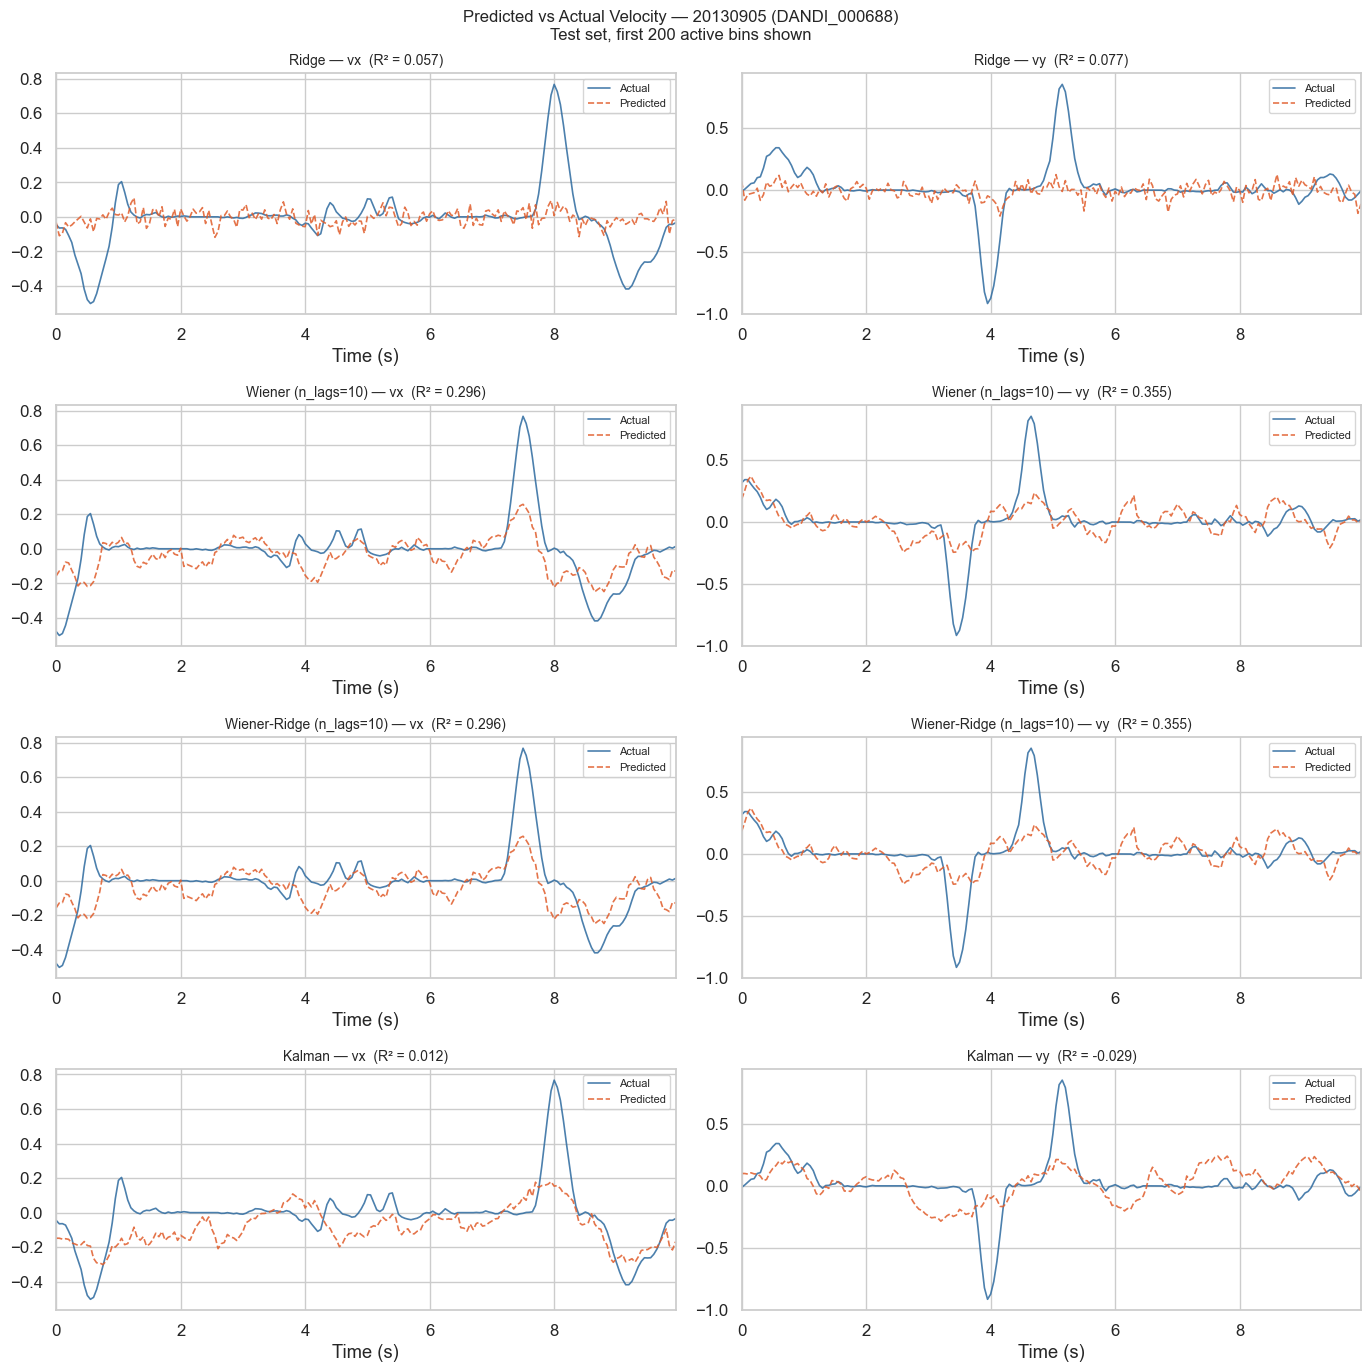

Saved: 01_ContinuousDecoding_DANDI688_velocity.png


In [32]:
pb_r = min(PLOT_BINS, len(y_test))
pb_w = min(PLOT_BINS, len(y_test_wiener))
pb_wr = min(PLOT_BINS, len(y_test_wiener_ridge))
pb_k = min(PLOT_BINS, len(y_test))
t_r  = np.arange(pb_r) * BIN_SIZE_MS / 1000
t_w  = np.arange(pb_w) * BIN_SIZE_MS / 1000
t_wr  = np.arange(pb_wr) * BIN_SIZE_MS / 1000
t_k  = np.arange(pb_k) * BIN_SIZE_MS / 1000

def _plot(ax, t, y_true, y_pred, r2_val, title):
    ax.plot(t, y_true, color="#2d6a9f", lw=1.2, label="Actual",    alpha=0.85)
    ax.plot(t, y_pred, color="#e05c2a", lw=1.2, label="Predicted", ls="--", alpha=0.85)
    ax.set_title(f"{title}  (R² = {r2_val:.3f})", fontsize=10)
    ax.set_xlabel("Time (s)")
    ax.legend(fontsize=8, loc="upper right")
    ax.set_xlim(t[0], t[-1])

fig, axes = plt.subplots(4, 2, figsize=(14, 14))
fig.suptitle(
    f"Predicted vs Actual Velocity — {session_id} (DANDI_000688)\n"
    f"Test set, first {PLOT_BINS} active bins shown",
    fontsize=12,
)

_plot(axes[0, 0], t_r, y_test[:pb_r, 0], y_pred_ridge[:pb_r, 0],   r2_ridge[0],  "Ridge — vx")
_plot(axes[0, 1], t_r, y_test[:pb_r, 1], y_pred_ridge[:pb_r, 1],   r2_ridge[1],  "Ridge — vy")
_plot(axes[1, 0], t_w, y_test_wiener[:pb_w, 0], y_pred_wiener[:pb_w, 0], r2_wiener[0], f"Wiener (n_lags={N_LAGS}) — vx")
_plot(axes[1, 1], t_w, y_test_wiener[:pb_w, 1], y_pred_wiener[:pb_w, 1], r2_wiener[1], f"Wiener (n_lags={N_LAGS}) — vy")
_plot(axes[2, 0], t_wr, y_test_wiener_ridge[:pb_wr, 0], y_pred_wiener_ridge[:pb_wr, 0], r2_wiener_ridge[0], f"Wiener-Ridge (n_lags={N_LAGS}) — vx")
_plot(axes[2, 1], t_wr, y_test_wiener_ridge[:pb_wr, 1], y_pred_wiener_ridge[:pb_wr, 1], r2_wiener_ridge[1], f"Wiener-Ridge (n_lags={N_LAGS}) — vy")
_plot(axes[3, 0], t_k, y_test[:pb_k, 0], y_pred_kalman[:pb_k, 0], r2_kalman[0], "Kalman — vx")
_plot(axes[3, 1], t_k, y_test[:pb_k, 1], y_pred_kalman[:pb_k, 1], r2_kalman[1], "Kalman — vy")

plt.tight_layout()
plt.savefig("01_ContinuousDecoding_DANDI688_velocity.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: 01_ContinuousDecoding_DANDI688_velocity.png")